### With the new convergence method that was just developed (torsion, alpha carbon, contact) Frobenius and JSD - retroanalyze if a previously run simulation would have converged.

In [1]:
import os, sys, glob

In [2]:
#Anna CB2
sim_dirs = [direc for direc in sorted(glob.glob('/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/*/')) if 'apo' not in direc]
top_fns = [direc for direc in sorted(glob.glob('/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/*.pdb')) if 'apo' not in direc]
analysis_large_dir = '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Anna_CB2_Full/'

In [3]:
#Aiman 5HT2A
sim_dirs = [direc for direc in sorted(glob.glob('/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/*/')) if 'apo' not in direc]
top_fns = [direc for direc in sorted(glob.glob('/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/*.pdb')) if 'apo' not in direc]
analysis_large_dir = '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/'

In [4]:
for sim_dir in sim_dirs:
    piece = sim_dir.split('/')[-2].split('_')
    name, rep = piece if len(piece) == 2 else ('_'.join(piece[:-1]), piece[-1])
    #print(name)
    likely_top = [elem for elem in top_fns if name in elem][0]
    #print(likely_top)
    analysis_dir = os.path.join(analysis_large_dir, name + '_2.0x1.0/')
    
    args = f"{sim_dir} {likely_top} --output_cache_dir {analysis_dir}"
    print(args)
    #print(f"sbatch run_retro.job {args}")

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25-N-NBI_0/ /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/25-N-NBI.pdb --output_cache_dir /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25-N-NBI_2.0x1.0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25N-N1-Nap_0/ /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/25N-N1-Nap.pdb --output_cache_dir /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-N1-Nap_2.0x1.0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25N-NBOMe_0/ /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/25N-NBOMe.pdb --output_cache_dir /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25N-NBPh_0/ /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/25N-NBPh.pdb --output_cache_dir /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-N

In [5]:
from chimpss.fultonmarket import FultonMarketAnalysis

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



jax:    0.7.2
jaxlib: 0.7.2
numpy:  2.3.5
python: 3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 16:05:46) [GCC 13.3.0]
device info: Tesla V100-SXM2-32GB-1, 1 local devices"
process_count: 1
platform: uname_result(system='Linux', node='exp-4-59', release='4.18.0-513.24.1.el8_9.x86_64', version='#1 SMP Thu Apr 4 18:13:02 UTC 2024', machine='x86_64')

$ nvidia-smi
Mon Apr  6 13:08:34 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  On   | 0

In [6]:
from chimpss.fultonmarket import plot_convergence_metric, add_equil_metric_to_plot
from chimpss.fultonmarket.retro_convergence import _RETRO_COLOR_MAP as color_map


In [7]:
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25-N-NBI_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/25-N-NBI.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25-N-NBI_2.0x1.0/
./figures/5HT2A_retro_convergence/25-N-NBI_0_convergence.png
04/06/2026 13:08:42 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25-N-NBI_0/saved_variables



******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************



04/06/2026 13:09:49 // Final energy matrix shape: (8493, 144, 144)
04/06/2026 13:09:52 // sim_no=4: computing matrices


Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 7.988118e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 13:12:40 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25-N-NBI_2.0x1.0/saved_variables/4/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25-N-NBI_2.0x1.0/saved_variables/4/resampled_trj.dcd
STDOUT:
 Detected 46410 solvent atoms (resname HOH)
Detected 11792 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 47 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25-N-NBI_2.0x1.0/saved_variables/4/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 64.179088 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 64.042015 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 64.176009 s
Finished computi

Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 13:16:11 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25-N-NBI_2.0x1.0/saved_variables/30/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25-N-NBI_2.0x1.0/saved_variables/30/resampled_trj.dcd
STDOUT:
 Detected 46410 solvent atoms (resname HOH)
Detected 11792 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 47 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25-N-NBI_2.0x1.0/saved_variables/30/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 63.655468 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 63.885642 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 63.743655 s
Finished comp

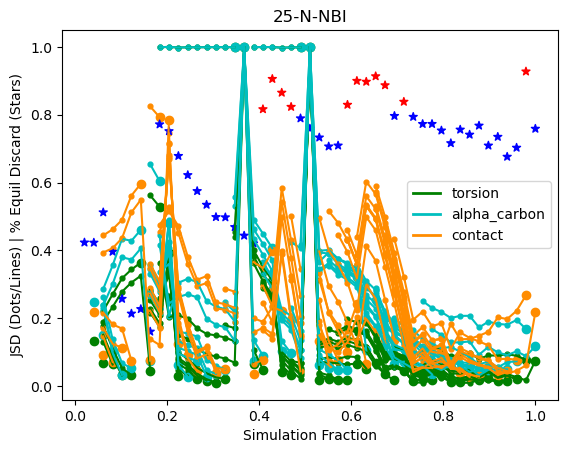

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25N-N1-Nap_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/25N-N1-Nap.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-N1-Nap_2.0x1.0/
./figures/5HT2A_retro_convergence/25N-N1-Nap_0_convergence.png
04/06/2026 13:20:49 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25N-N1-Nap_0/saved_variables
04/06/2026 13:21:41 // Final energy matrix shape: (7129, 145, 145)
04/06/2026 13:22:07 // retro_analyze_all complete: 42 / 42 processed.
04/06/2026 13:22:07 // retro_convergence_report: 42 checkpoints, total_n_sims=42 (100.0% of simulation covered), frobenius_thresh=0.01, jsd_thresh=0.1


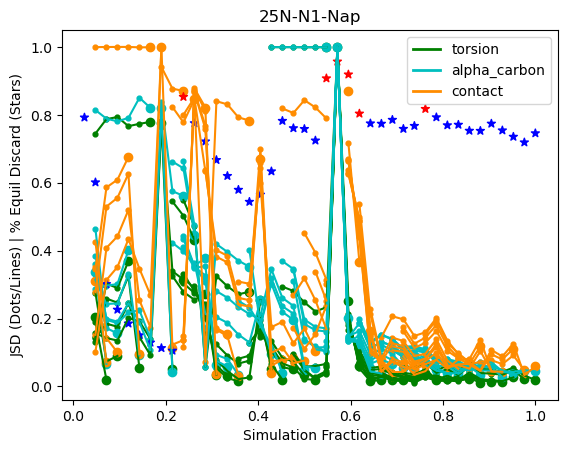

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25N-NBOMe_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/25N-NBOMe.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/
./figures/5HT2A_retro_convergence/25N-NBOMe_0_convergence.png
04/06/2026 13:23:15 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25N-NBOMe_0/saved_variables
04/06/2026 13:24:34 // Final energy matrix shape: (8868, 151, 151)
04/06/2026 13:24:37 // sim_no=8: computing matrices


Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 8.805916e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 13:28:03 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/saved_variables/8/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/saved_variables/8/resampled_trj.dcd
STDOUT:
 Detected 46356 solvent atoms (resname HOH)
Detected 11926 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 47 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/saved_variables/8/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 63.321111 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 63.651363 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 63.644279 s
Finished comp

Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 6.797334e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 13:32:33 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/saved_variables/12/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/saved_variables/12/resampled_trj.dcd
STDOUT:
 Detected 46356 solvent atoms (resname HOH)
Detected 11926 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 47 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/saved_variables/12/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 63.542296 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 63.626083 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 63.988745 s
Finished c

Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 7.201500e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 13:36:17 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/saved_variables/15/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/saved_variables/15/resampled_trj.dcd
STDOUT:
 Detected 46356 solvent atoms (resname HOH)
Detected 11926 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 47 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBOMe_2.0x1.0/saved_variables/15/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 64.460608 s
Finished computing contacts for fragment 3: 100 frames from 300 to 399 in strides of 1 taking 64.276959 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 64.632077 s
Finished c

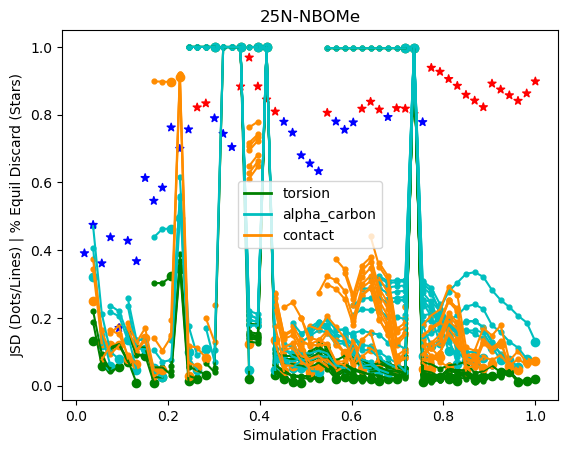

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25N-NBPh_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/25N-NBPh.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBPh_2.0x1.0/
./figures/5HT2A_retro_convergence/25N-NBPh_0_convergence.png
04/06/2026 13:41:16 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/25N-NBPh_0/saved_variables
04/06/2026 13:42:06 // Final energy matrix shape: (5846, 146, 146)
04/06/2026 13:42:07 // sim_no=2: computing matrices


Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 3.516146e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 13:43:53 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBPh_2.0x1.0/saved_variables/2/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBPh_2.0x1.0/saved_variables/2/resampled_trj.dcd
STDOUT:
 Detected 46428 solvent atoms (resname HOH)
Detected 11792 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 53 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBPh_2.0x1.0/saved_variables/2/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 63.972108 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 64.16376 s
Finished computing contacts for fragment 3: 100 frames from 300 to 399 in strides of 1 taking 64.083039 s
Finished computin

Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 13:47:36 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBPh_2.0x1.0/saved_variables/8/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBPh_2.0x1.0/saved_variables/8/resampled_trj.dcd
STDOUT:
 Detected 46428 solvent atoms (resname HOH)
Detected 11792 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 53 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/25N-NBPh_2.0x1.0/saved_variables/8/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 4: 100 frames from 400 to 499 in strides of 1 taking 64.329345 s
Finished computing contacts for fragment 3: 100 frames from 300 to 399 in strides of 1 taking 64.477239 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 64.677899 s
Finished comp

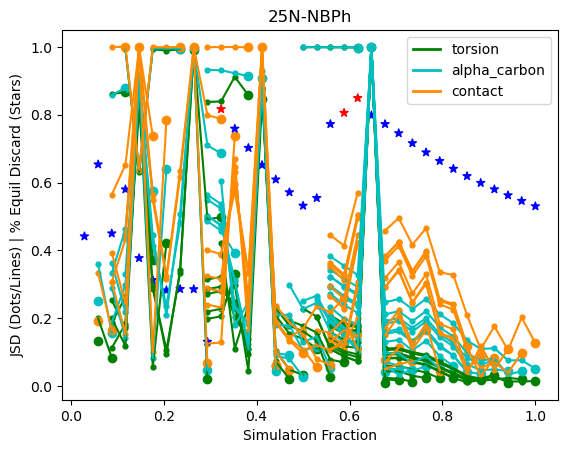

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/6wha_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/6wha.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/6wha_2.0x1.0/
./figures/5HT2A_retro_convergence/6wha_0_convergence.png
04/06/2026 13:50:49 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/6wha_0/saved_variables
04/06/2026 13:51:39 // Final energy matrix shape: (8557, 142, 142)
04/06/2026 13:51:40 // sim_no=3: computing matrices


Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 6.803998e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 13:54:24 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/6wha_2.0x1.0/saved_variables/3/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/6wha_2.0x1.0/saved_variables/3/resampled_trj.dcd
STDOUT:
 Detected 46461 solvent atoms (resname HOH)
Detected 11658 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 43 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/6wha_2.0x1.0/saved_variables/3/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 63.775427 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 63.6861 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 63.937831 s
Finished computing contacts fo

Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 6.483391e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 13:59:06 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/6wha_2.0x1.0/saved_variables/24/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/6wha_2.0x1.0/saved_variables/24/resampled_trj.dcd
STDOUT:
 Detected 46461 solvent atoms (resname HOH)
Detected 11658 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 43 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/6wha_2.0x1.0/saved_variables/24/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 63.186618 s
Finished computing contacts for fragment 4: 100 frames from 400 to 499 in strides of 1 taking 63.186997 s
Finished computing contacts for fragment 3: 100 frames from 300 to 399 in strides of 1 taking 63.337554 s
Finished computing con

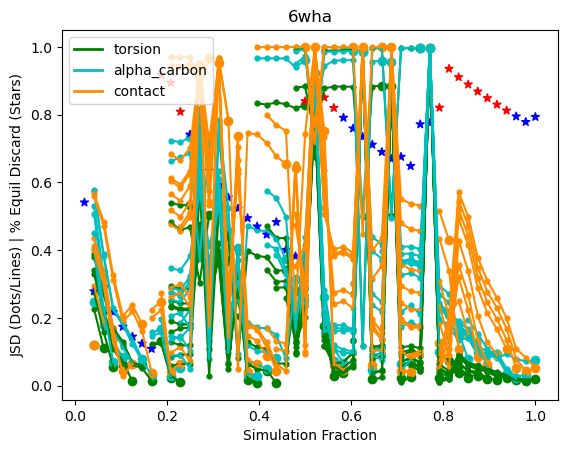

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/7voe_fixed_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/7voe_fixed.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/7voe_fixed_2.0x1.0/
./figures/5HT2A_retro_convergence/7voe_fixed_0_convergence.png
04/06/2026 14:03:10 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/7voe_fixed_0/saved_variables
04/06/2026 14:04:20 // Final energy matrix shape: (9735, 137, 137)
04/06/2026 14:06:15 // retro_analyze_all complete: 54 / 54 processed.
04/06/2026 14:06:15 // retro_convergence_report: 54 checkpoints, total_n_sims=54 (100.0% of simulation covered), frobenius_thresh=0.01, jsd_thresh=0.1


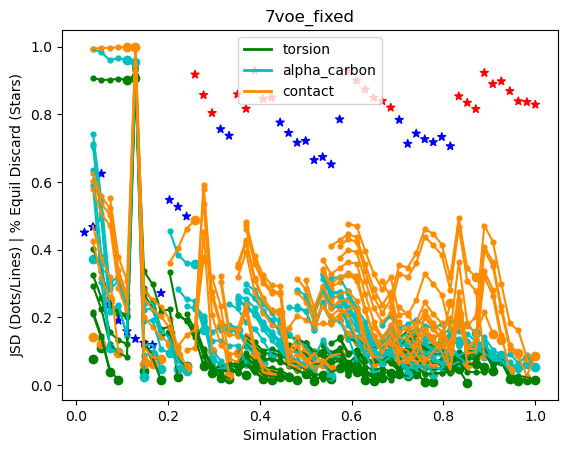

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/8JT8_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/8JT8.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/
./figures/5HT2A_retro_convergence/8JT8_0_convergence.png
04/06/2026 14:08:48 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/8JT8_0/saved_variables
04/06/2026 14:13:28 // Final energy matrix shape: (7719, 146, 146)
04/06/2026 14:13:31 // sim_no=6: computing matrices


Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 14:15:02 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables/6/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables/6/resampled_trj.dcd
STDOUT:
 Detected 47427 solvent atoms (resname HOH)
Detected 13132 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 52 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables/6/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 64.19779 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 64.479227 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 64.562793 s
Finished computing contacts f

Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 5.695674e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 14:18:34 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables/17/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables/17/resampled_trj.dcd
STDOUT:
 Detected 47427 solvent atoms (resname HOH)
Detected 13132 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 52 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables/17/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 66.297589 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 66.21523 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 66.337343 s
Finished computing contact

Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 14:23:24 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables/24/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables/24/resampled_trj.dcd
STDOUT:
 Detected 47427 solvent atoms (resname HOH)
Detected 13132 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 52 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/8JT8_2.0x1.0/saved_variables/24/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 65.554351 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 65.405428 s
Finished computing contacts for fragment 4: 100 frames from 400 to 499 in strides of 1 taking 65.155128 s
Finished computing contac

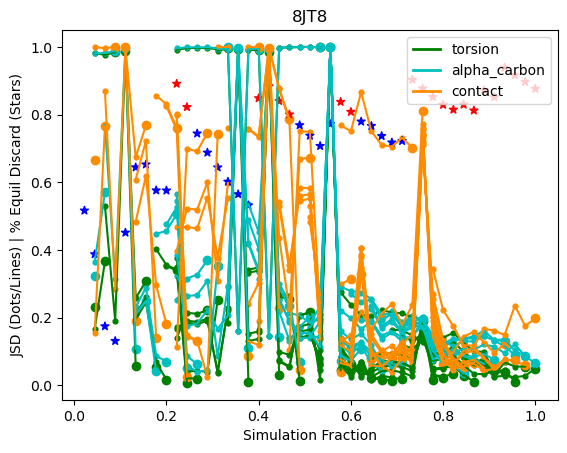

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/DOI_analogue_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/DOI_analogue.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/DOI_analogue_2.0x1.0/
./figures/5HT2A_retro_convergence/DOI_analogue_0_convergence.png
04/06/2026 14:27:17 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/DOI_analogue_0/saved_variables
04/06/2026 14:28:17 // Final energy matrix shape: (8954, 148, 148)
04/06/2026 14:28:20 // sim_no=4: computing matrices


Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 7.080624e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 14:30:55 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/DOI_analogue_2.0x1.0/saved_variables/4/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/DOI_analogue_2.0x1.0/saved_variables/4/resampled_trj.dcd
STDOUT:
 Detected 45186 solvent atoms (resname HOH)
Detected 12864 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 31 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/DOI_analogue_2.0x1.0/saved_variables/4/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 64.312158 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 64.413244 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 64.79725 s
Finis

Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 14:35:11 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/DOI_analogue_2.0x1.0/saved_variables/10/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/DOI_analogue_2.0x1.0/saved_variables/10/resampled_trj.dcd
STDOUT:
 Detected 45186 solvent atoms (resname HOH)
Detected 12864 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 31 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/DOI_analogue_2.0x1.0/saved_variables/10/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 64.34043 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 64.751758 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 64.69735 s
Fin

Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 14:44:15 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/DOI_analogue_2.0x1.0/saved_variables/15/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/DOI_analogue_2.0x1.0/saved_variables/15/resampled_trj.dcd
STDOUT:
 Detected 45186 solvent atoms (resname HOH)
Detected 12864 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 31 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/DOI_analogue_2.0x1.0/saved_variables/15/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 64.510221 s
Finished computing contacts for fragment 4: 100 frames from 400 to 499 in strides of 1 taking 64.119302 s
Finished computing contacts for fragment 3: 100 frames from 300 to 399 in strides of 1 taking 64.659467 s
F

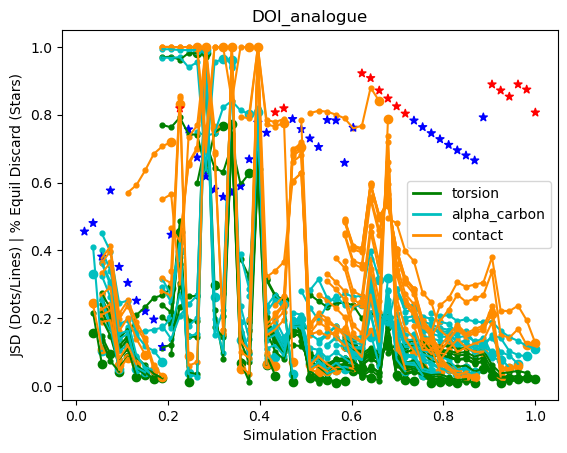

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7079_analogue_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/IHCH-7079_analogue.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7079_analogue_2.0x1.0/
./figures/5HT2A_retro_convergence/IHCH-7079_analogue_0_convergence.png
04/06/2026 14:49:39 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7079_analogue_0/saved_variables
04/06/2026 14:50:56 // Final energy matrix shape: (8170, 145, 145)
04/06/2026 14:51:01 // sim_no=12: computing matrices


Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 8.328000e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 14:52:40 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7079_analogue_2.0x1.0/saved_variables/12/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7079_analogue_2.0x1.0/saved_variables/12/resampled_trj.dcd
STDOUT:
 Detected 47262 solvent atoms (resname HOH)
Detected 11792 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 56 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7079_analogue_2.0x1.0/saved_variables/12/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 65.04464 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 65.245209 s
Finished computing contacts for fragment 3: 100 frames from 300 to 399 in strides of 1 tak

Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 14:56:19 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7079_analogue_2.0x1.0/saved_variables/27/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7079_analogue_2.0x1.0/saved_variables/27/resampled_trj.dcd
STDOUT:
 Detected 47262 solvent atoms (resname HOH)
Detected 11792 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 56 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7079_analogue_2.0x1.0/saved_variables/27/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 64.851662 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 65.425558 s
Finished computing contacts for fragment 5: 100 frames from 500 to 599 in strides of 1 ta

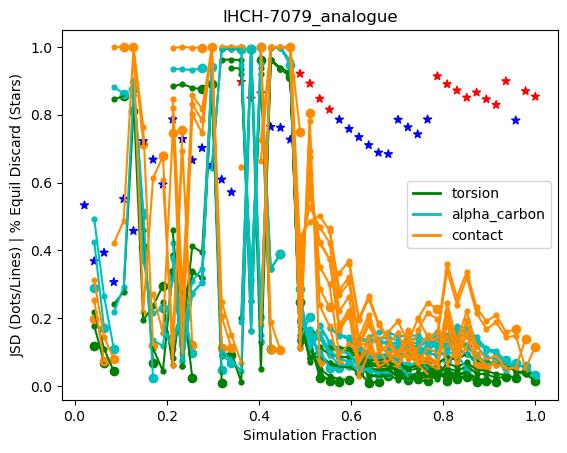

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7086_analogue_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/IHCH-7086_analogue.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/
./figures/5HT2A_retro_convergence/IHCH-7086_analogue_0_convergence.png
04/06/2026 15:00:33 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7086_analogue_0/saved_variables
04/06/2026 15:01:46 // Final energy matrix shape: (12195, 148, 148)
04/06/2026 15:02:04 // sim_no=23: computing matrices


Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 2.383986e+06 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 15:04:36 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/23/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/23/resampled_trj.dcd
STDOUT:
 Detected 47322 solvent atoms (resname HOH)
Detected 12060 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 59 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/23/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 65.514403 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 65.555105 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 ta

Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 1.176062e+04 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 15:11:05 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/24/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/24/resampled_trj.dcd
STDOUT:
 Detected 47322 solvent atoms (resname HOH)
Detected 12060 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 59 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/24/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 66.201385 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 66.402812 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 ta

...

04/06/2026 15:30:58 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/69/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/69/resampled_trj.dcd
STDOUT:
 Detected 47322 solvent atoms (resname HOH)
Detected 12060 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 59 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/69/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 65.076577 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 65.161693 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 ta

Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 15:35:47 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/70/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/70/resampled_trj.dcd
STDOUT:
 Detected 47322 solvent atoms (resname HOH)
Detected 12060 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 59 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/70/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 4: 100 frames from 400 to 499 in strides of 1 taking 64.852199 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 65.267812 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 ta

Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 15:40:12 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/71/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/71/resampled_trj.dcd
STDOUT:
 Detected 47322 solvent atoms (resname HOH)
Detected 12060 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 59 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7086_analogue_2.0x1.0/saved_variables/71/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 64.784887 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 65.395077 s
Finished computing contacts for fragment 4: 100 frames from 400 to 499 in strides of 1 ta

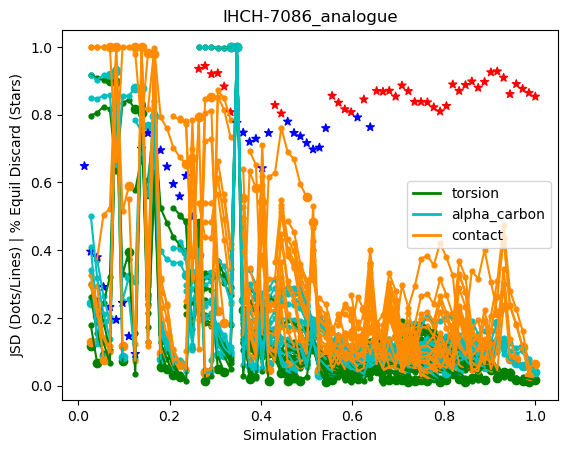

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7087_analogue_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/IHCH-7087_analogue.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7087_analogue_2.0x1.0/
./figures/5HT2A_retro_convergence/IHCH-7087_analogue_0_convergence.png
04/06/2026 15:47:36 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7087_analogue_0/saved_variables
04/06/2026 15:48:37 // Final energy matrix shape: (7589, 148, 148)
04/06/2026 15:48:38 // sim_no=2: computing matrices


Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 4.049535e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 15:50:45 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7087_analogue_2.0x1.0/saved_variables/2/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7087_analogue_2.0x1.0/saved_variables/2/resampled_trj.dcd
STDOUT:
 Detected 47289 solvent atoms (resname HOH)
Detected 11926 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 56 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7087_analogue_2.0x1.0/saved_variables/2/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 64.142695 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 64.401539 s
Finished computing contacts for fragment 4: 100 frames from 400 to 499 in strides of 1 ta

Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 15:54:33 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7087_analogue_2.0x1.0/saved_variables/7/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7087_analogue_2.0x1.0/saved_variables/7/resampled_trj.dcd
STDOUT:
 Detected 47289 solvent atoms (resname HOH)
Detected 11926 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 56 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7087_analogue_2.0x1.0/saved_variables/7/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 64.616173 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 65.160876 s
Finished computing contacts for fragment 4: 100 frames from 400 to 499 in strides of 1 takin

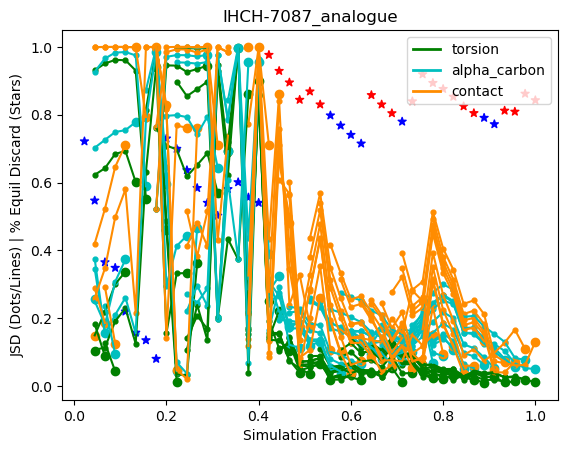

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7088_analogue_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/IHCH-7088_analogue.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7088_analogue_2.0x1.0/
./figures/5HT2A_retro_convergence/IHCH-7088_analogue_0_convergence.png
04/06/2026 15:58:34 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7088_analogue_0/saved_variables
04/06/2026 15:59:31 // Final energy matrix shape: (7895, 143, 143)
04/06/2026 15:59:33 // sim_no=4: computing matrices


Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 2.966322e+58 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 16:01:33 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7088_analogue_2.0x1.0/saved_variables/4/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7088_analogue_2.0x1.0/saved_variables/4/resampled_trj.dcd
STDOUT:
 Detected 47355 solvent atoms (resname HOH)
Detected 11658 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 56 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7088_analogue_2.0x1.0/saved_variables/4/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 64.057047 s
Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 63.869072 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 takin

Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 9.008109e+113 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 16:05:06 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7088_analogue_2.0x1.0/saved_variables/7/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7088_analogue_2.0x1.0/saved_variables/7/resampled_trj.dcd
STDOUT:
 Detected 47355 solvent atoms (resname HOH)
Detected 11658 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 56 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7088_analogue_2.0x1.0/saved_variables/7/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 64.395284 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 64.653889 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 takin

Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 16:08:35 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7088_analogue_2.0x1.0/saved_variables/19/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7088_analogue_2.0x1.0/saved_variables/19/resampled_trj.dcd
STDOUT:
 Detected 47355 solvent atoms (resname HOH)
Detected 11658 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 56 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7088_analogue_2.0x1.0/saved_variables/19/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 taking 64.054078 s
Finished computing contacts for fragment 3: 100 frames from 300 to 399 in strides of 1 taking 64.182137 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 ta

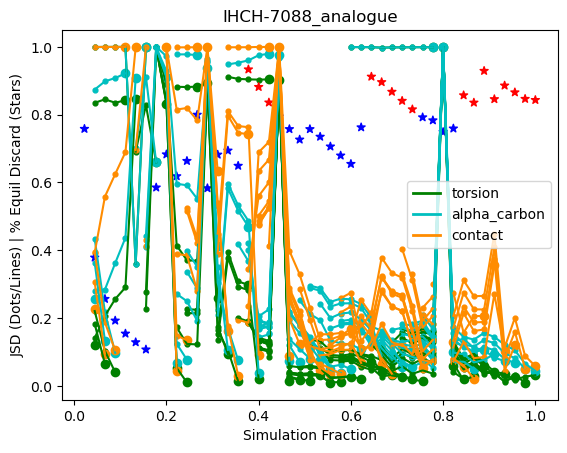

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7089_analogue_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/IHCH-7089_analogue.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7089_analogue_2.0x1.0/
./figures/5HT2A_retro_convergence/IHCH-7089_analogue_0_convergence.png
04/06/2026 16:12:30 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7089_analogue_0/saved_variables
04/06/2026 16:13:33 // Final energy matrix shape: (9759, 147, 147)
04/06/2026 16:13:37 // sim_no=9: computing matrices


Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 8.095641e+03 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 16:16:20 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7089_analogue_2.0x1.0/saved_variables/9/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7089_analogue_2.0x1.0/saved_variables/9/resampled_trj.dcd
STDOUT:
 Detected 47361 solvent atoms (resname HOH)
Detected 12060 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 59 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7089_analogue_2.0x1.0/saved_variables/9/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 65.483076 s
Finished computing contacts for fragment 4: 100 frames from 400 to 499 in strides of 1 taking 65.134734 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 takin

Failed to reach a solution to within tolerance with hybr: trying next method
max_delta = 0.000000e+00, tol = 1.000000e-12, maximum_iterations = 10000, iterations completed = 9999
Failed to reach a solution to within tolerance with adaptive: trying next method
No solution found to within tolerance.
The solution with the smallest gradient 1.256637e+04 norm is hybr
Please exercise caution with this solution and consider alternative methods or a different tolerance.


04/06/2026 16:20:34 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7089_analogue_2.0x1.0/saved_variables/11/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7089_analogue_2.0x1.0/saved_variables/11/resampled_trj.dcd
STDOUT:
 Detected 47361 solvent atoms (resname HOH)
Detected 12060 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 59 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7089_analogue_2.0x1.0/saved_variables/11/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 2: 100 frames from 200 to 299 in strides of 1 taking 65.144811 s
Finished computing contacts for fragment 0: 100 frames from 0 to 99 in strides of 1 taking 65.444733 s
Finished computing contacts for fragment 1: 100 frames from 100 to 199 in strides of 1 ta

Failed to reach a solution to within tolerance with hybr: trying next method


04/06/2026 16:24:37 // 1000 frames written to /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7089_analogue_2.0x1.0/saved_variables/32/resampled_top.pdb and /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7089_analogue_2.0x1.0/saved_variables/32/resampled_trj.dcd
STDOUT:
 Detected 47361 solvent atoms (resname HOH)
Detected 12060 lipid atoms (resnames POP) matching --lipid 'resname POP'
Detected 59 ligand atoms matching --ligand 'resname UNK'
Processing /expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7089_analogue_2.0x1.0/saved_variables/32/resampled_trj.dcd (frame 0 to 999 with stride of 1) as 10 fragments

Finished computing contacts for fragment 4: 100 frames from 400 to 499 in strides of 1 taking 64.204504 s
Finished computing contacts for fragment 3: 100 frames from 300 to 399 in strides of 1 taking 64.713883 s
Finished computing contacts for fragment 6: 100 frames from 600 to 699 in strides of 1

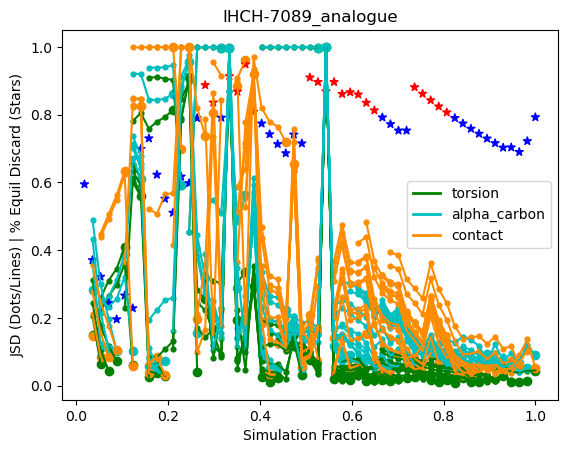

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7112_analogue_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/IHCH-7112_analogue.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7112_analogue_2.0x1.0/
./figures/5HT2A_retro_convergence/IHCH-7112_analogue_0_convergence.png
04/06/2026 16:29:44 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7112_analogue_0/saved_variables
04/06/2026 16:30:45 // Final energy matrix shape: (7938, 141, 141)
04/06/2026 16:31:08 // retro_analyze_all complete: 45 / 45 processed.
04/06/2026 16:31:08 // retro_convergence_report: 45 checkpoints, total_n_sims=45 (100.0% of simulation covered), frobenius_thresh=0.01, jsd_thresh=0.1


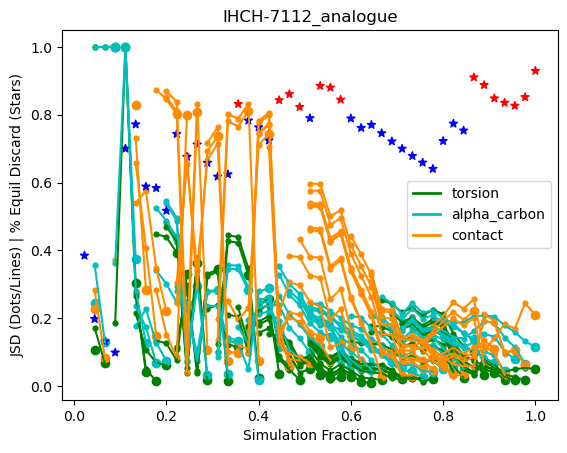

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7120_analogue_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/IHCH-7120_analogue.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/IHCH-7120_analogue_2.0x1.0/
./figures/5HT2A_retro_convergence/IHCH-7120_analogue_0_convergence.png
04/06/2026 16:32:37 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/IHCH-7120_analogue_0/saved_variables
04/06/2026 16:33:34 // Final energy matrix shape: (8184, 145, 145)
04/06/2026 16:33:55 // retro_analyze_all complete: 48 / 48 processed.
04/06/2026 16:33:55 // retro_convergence_report: 48 checkpoints, total_n_sims=48 (100.0% of simulation covered), frobenius_thresh=0.01, jsd_thresh=0.1


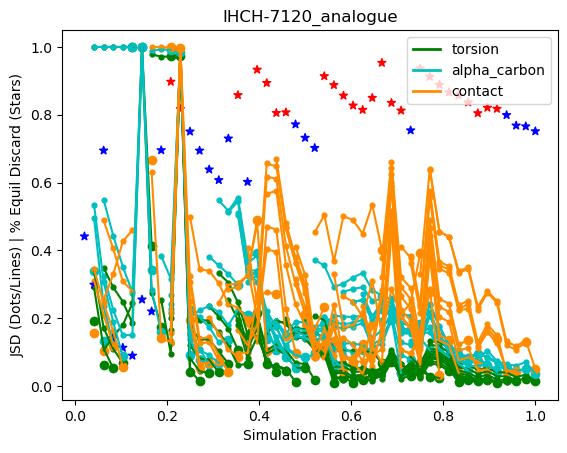

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7vod_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7vod.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7vod_2.0x1.0/
./figures/5HT2A_retro_convergence/fixed_7vod_0_convergence.png
04/06/2026 16:35:38 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7vod_0/saved_variables
04/06/2026 16:36:41 // Final energy matrix shape: (9781, 137, 137)
04/06/2026 16:37:02 // retro_analyze_all complete: 54 / 54 processed.
04/06/2026 16:37:02 // retro_convergence_report: 54 checkpoints, total_n_sims=54 (100.0% of simulation covered), frobenius_thresh=0.01, jsd_thresh=0.1


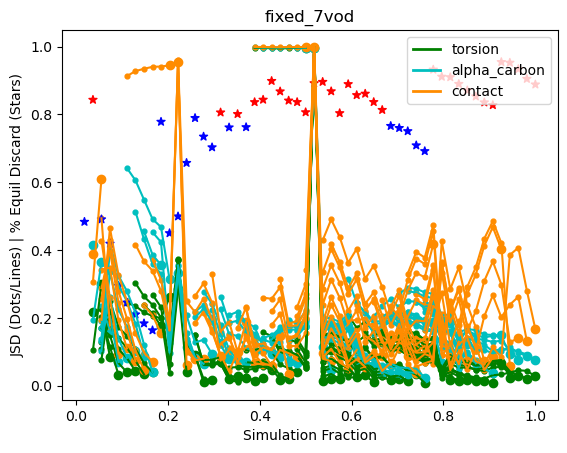

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc4_2.0x1.0/
./figures/5HT2A_retro_convergence/fixed_7wc4_0_convergence.png
04/06/2026 16:39:37 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/saved_variables
04/06/2026 16:40:29 // Final energy matrix shape: (9800, 136, 136)
04/06/2026 16:40:50 // retro_analyze_all complete: 54 / 54 processed.
04/06/2026 16:40:50 // retro_convergence_report: 54 checkpoints, total_n_sims=54 (100.0% of simulation covered), frobenius_thresh=0.01, jsd_thresh=0.1


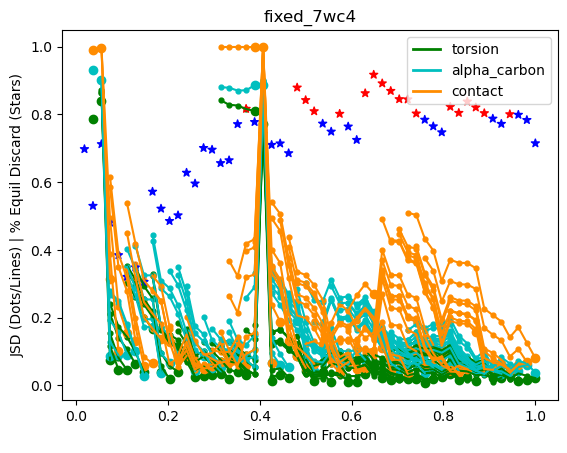

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc5_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc5.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc5_2.0x1.0/
./figures/5HT2A_retro_convergence/fixed_7wc5_0_convergence.png
04/06/2026 16:43:24 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc5_0/saved_variables
04/06/2026 16:44:12 // Final energy matrix shape: (9646, 135, 135)
04/06/2026 16:44:40 // retro_analyze_all complete: 53 / 53 processed.
04/06/2026 16:44:40 // retro_convergence_report: 53 checkpoints, total_n_sims=53 (100.0% of simulation covered), frobenius_thresh=0.01, jsd_thresh=0.1


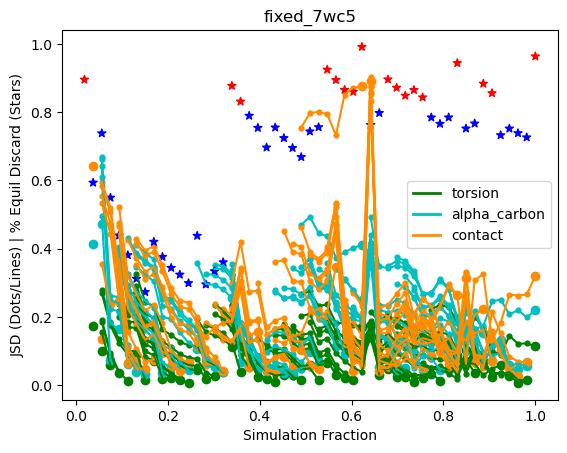

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc6_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc6.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc6_2.0x1.0/
./figures/5HT2A_retro_convergence/fixed_7wc6_0_convergence.png
04/06/2026 16:47:10 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc6_0/saved_variables
04/06/2026 16:47:48 // Final energy matrix shape: (8918, 135, 135)
04/06/2026 16:48:08 // retro_analyze_all complete: 49 / 49 processed.
04/06/2026 16:48:08 // retro_convergence_report: 49 checkpoints, total_n_sims=49 (100.0% of simulation covered), frobenius_thresh=0.01, jsd_thresh=0.1


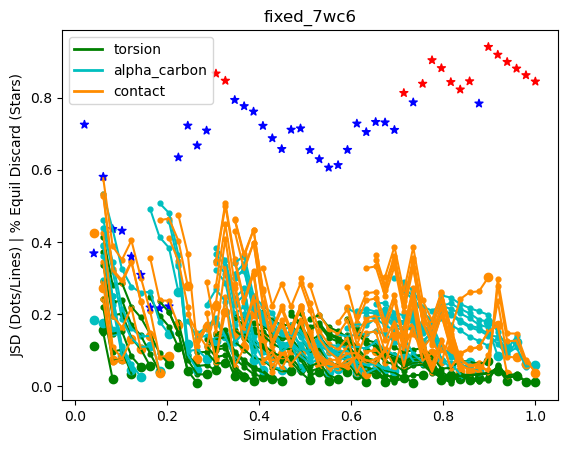

/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc7_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc7.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/Aiman_5HT2A_Full/fixed_7wc7_2.0x1.0/
./figures/5HT2A_retro_convergence/fixed_7wc7_0_convergence.png
04/06/2026 16:50:07 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc7_0/saved_variables
04/06/2026 16:50:58 // Final energy matrix shape: (9770, 136, 136)
04/06/2026 16:51:18 // retro_analyze_all complete: 54 / 54 processed.
04/06/2026 16:51:18 // retro_convergence_report: 54 checkpoints, total_n_sims=54 (100.0% of simulation covered), frobenius_thresh=0.01, jsd_thresh=0.1


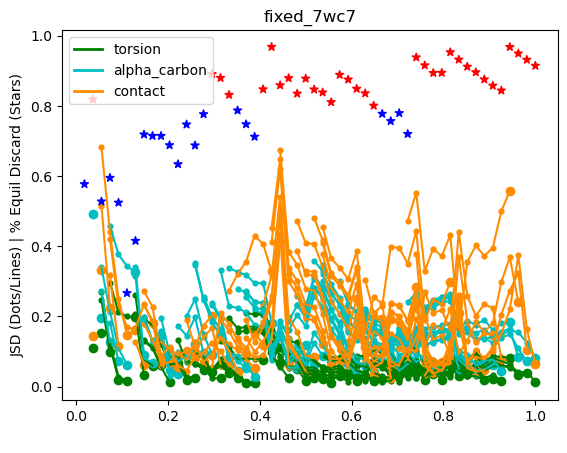

In [8]:
fig_dir = './figures/5HT2A_retro_convergence/'
if not os.path.isdir(fig_dir):
    os.makedirs(fig_dir)

history=True
func='jsd'
    

for sim_dir in sim_dirs:
    piece = sim_dir.split('/')[-2].split('_')
    name, rep = piece if len(piece) == 2 else ('_'.join(piece[:-1]), piece[-1])
    #print(name)
    likely_top = [elem for elem in top_fns if name in elem][0]
    #print(likely_top)
    analysis_dir = os.path.join(analysis_large_dir, name + '_2.0x1.0/')
    fig_name = os.path.join(fig_dir, f"{name}_{rep}_convergence.png")

    print(sim_dir)
    print(likely_top)
    print(analysis_dir)
    print(fig_name)
    
    analyzer = FultonMarketAnalysis(input_dir=sim_dir,
                                    pdb=likely_top,
                                    sele_str='resname UNK')
    
    matrices = analyzer.retro_analyze_all(n_resample=1000,
                                          output_cache_dir=analysis_dir,
                                          getcontacts_script='/expanse/lustre/projects/uil133/josephdb/getcontacts/get_dynamic_contacts.py',
                                          conda_env='pyinteraph2',
                                          getcontacts_python=os.path.join(os.environ['CONDA_PREFIX'].replace('replica2','pyinteraph2'),'bin','python'))
    
    report, metrics = analyzer.retro_convergence_report(n_resample=1000, output_cache_dir=analysis_dir,
                                                        frobenius_thresh=0.01, jsd_thresh=0.10)
    
    plt.clf()
    plot_convergence_metric(metrics, func=func, distype='torsion', history=history)
    plot_convergence_metric(metrics, func=func, distype='alpha_carbon', history=history)
    plot_convergence_metric(metrics, func=func, distype='contact', history=history)
    add_equil_metric_to_plot(metrics)
    lines, keys = [Line2D([0], [0], color=color_map[key], lw=2) for key in color_map.keys()], [key for key in color_map.keys()]
    plt.legend(lines, keys)
    plt.xlabel('Simulation Fraction')
    plt.ylabel('JSD (Dots/Lines) | % Equil Discard (Stars)')
    plt.title(name)
    plt.savefig(fig_name, dpi=900, bbox_inches='tight')
    plt.show()

In [3]:
#Aiman, 5HT2A
simu_direcs = [
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange2/fixed_7wc4_2/',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange/fixed_7wc4_1/',
]

tops_filenames = [
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
]

archive_directories = [
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_2/',
]

In [4]:
import os
analyzers = []
matriceses = []
reports = []
metricses = []

for i, (direc_in, pdb_in, cache_dir) in enumerate(zip(simu_direcs, tops_filenames, archive_directories)):
    print('############################################################################')
    print(direc_in)
    print(pdb_in)
    print(cache_dir)
    
    analyzer = FultonMarketAnalysis(input_dir=direc_in,
                                    pdb=pdb_in,
                                    sele_str='resname UNK')
    
    matrices = analyzer.retro_analyze_all(n_resample=1000,
                                          output_cache_dir=cache_dir,
                                          getcontacts_script='/expanse/lustre/projects/uil133/josephdb/getcontacts/get_dynamic_contacts.py',
                                          conda_env='pyinteraph2',
                                          getcontacts_python=os.path.join(os.environ['CONDA_PREFIX'].replace('replica2','pyinteraph2'),'bin','python'))
    report, metrics = analyzer.retro_convergence_report(n_resample=1000, output_cache_dir=cache_dir,
                                                frobenius_thresh=0.01, jsd_thresh=0.10)
    analyzers.append(analyzer)
    matriceses.append(matrices)
    reports.append(report)
    metricses.append(metrics)

############################################################################
/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/
04/05/2026 18:13:49 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/saved_variables



******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************



04/05/2026 18:14:43 // Final energy matrix shape: (9800, 136, 136)
04/05/2026 18:15:10 // retro_analyze_all complete: 54 / 54 processed.
04/05/2026 18:15:10 // retro_convergence_report: 54 checkpoints, total_n_sims=54 (100.0% of simulation covered), frobenius_thresh=0.01, jsd_thresh=0.1



KeyboardInterrupt

Exception ignored in: <function _xla_gc_callback at 0x155533921800>
Traceback (most recent call last):
  File "/home/josephdb/miniconda3/envs/replica2/lib/python3.12/site-packages/jax/_src/lib/__init__.py", line 127, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 

KeyboardInterrupt



In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
titles = ['5HT2A_7WC4_0', '5HT2A_7WC4_1', '5HT2A_7WC4_2',
          # 'AM630_0', 'AM630_1', 'AM630_2',
          # 'RS1125_0', 'RS1125_1', 'RS1125_2',
          # #'RS1126_0', 'RS1126_1', 'RS1126_2',
          # 'AM630_HMR_0', 'AM630_HMR_1', 'AM630_HMR_2',
          # '5HT2B_LSD_7SRQ', '5HT2B_LSD_7SRR', '5HT2B_LSD_7SRS',
         ]

for i, metrics in enumerate(metricses):
    plt.clf()
    history=True
    func='jsd'
    plot_convergence_metric(metrics, func=func, distype='torsion', history=history)
    plot_convergence_metric(metrics, func=func, distype='alpha_carbon', history=history)
    plot_convergence_metric(metrics, func=func, distype='contact', history=history)
    add_equil_metric_to_plot(metrics)
    lines, keys = [Line2D([0], [0], color=color_map[key], lw=2) for key in color_map.keys()], [key for key in color_map.keys()]
    plt.legend(lines, keys)
    plt.xlabel('Simulation Fraction')
    plt.ylabel('JSD (Dots/Lines) | % Equil Discard (Stars)')
    plt.title(titles[i])
    plt.show()

In [ ]:
#Anna, CB2 - AM630
simu_direcs = [
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/AM630_0/',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/AM630_1/',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/AM630_2/',
]

tops_filenames = [
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
]

archive_directories = [
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_2.0x1.0_2/',   
]

In [ ]:
import os
analyzers = []
matriceses = []
reports = []
metricses = []

for i, (direc_in, pdb_in, cache_dir) in enumerate(zip(simu_direcs, tops_filenames, archive_directories)):
    print('############################################################################')
    print(direc_in)
    print(pdb_in)
    print(cache_dir)
    
    analyzer = FultonMarketAnalysis(input_dir=direc_in,
                                    pdb=pdb_in,
                                    sele_str='resname UNK')
    
    matrices = analyzer.retro_analyze_all(n_resample=1000,
                                          output_cache_dir=cache_dir,
                                          getcontacts_script='/expanse/lustre/projects/uil133/josephdb/getcontacts/get_dynamic_contacts.py',
                                          conda_env='pyinteraph2',
                                          getcontacts_python=os.path.join(os.environ['CONDA_PREFIX'].replace('replica2','pyinteraph2'),'bin','python'))
    report, metrics = analyzer.retro_convergence_report(n_resample=1000, output_cache_dir=cache_dir,
                                                frobenius_thresh=0.01, jsd_thresh=0.10)
    analyzers.append(analyzer)
    matriceses.append(matrices)
    reports.append(report)
    metricses.append(metrics)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
titles = [#'5HT2A_7WC4_0', '5HT2A_7WC4_1', '5HT2A_7WC4_2',
          'AM630_0', 'AM630_1', 'AM630_2',
          #'RS1125_0', 'RS1125_1', 'RS1125_2',
          #'RS1126_0', 'RS1126_1', 'RS1126_2',
          #'AM630_HMR_0', 'AM630_HMR_1', 'AM630_HMR_2',
          #'5HT2B_LSD_7SRQ', '5HT2B_LSD_7SRR', '5HT2B_LSD_7SRS'
]

for i, metrics in enumerate(metricses):
    plt.clf()
    history=True
    func='jsd'
    plot_convergence_metric(metrics, func=func, distype='torsion', history=history)
    plot_convergence_metric(metrics, func=func, distype='alpha_carbon', history=history)
    plot_convergence_metric(metrics, func=func, distype='contact', history=history)
    add_equil_metric_to_plot(metrics)
    lines, keys = [Line2D([0], [0], color=color_map[key], lw=2) for key in color_map.keys()], [key for key in color_map.keys()]
    plt.legend(lines, keys)
    plt.xlabel('Simulation Fraction')
    plt.ylabel('JSD (Dots/Lines) | % Equil Discard (Stars)')
    plt.title(titles[i])
    plt.show()

In [ ]:
#Me, KOR - RS1125
simu_direcs = [
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1125_0/',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1125_1/',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1125_2/',
    ]

tops_filenames = [
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1125.pdb',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1125.pdb',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1125.pdb',
    ]

archive_directories = [
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1125_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1125_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1125_2.0x1.0_2/',
    ]

In [ ]:
import os
analyzers = []
matriceses = []
reports = []
metricses = []

for i, (direc_in, pdb_in, cache_dir) in enumerate(zip(simu_direcs, tops_filenames, archive_directories)):
    print('############################################################################')
    print(direc_in)
    print(pdb_in)
    print(cache_dir)
    
    analyzer = FultonMarketAnalysis(input_dir=direc_in,
                                    pdb=pdb_in,
                                    sele_str='resname UNK')
    
    matrices = analyzer.retro_analyze_all(n_resample=1000,
                                          output_cache_dir=cache_dir,
                                          getcontacts_script='/expanse/lustre/projects/uil133/josephdb/getcontacts/get_dynamic_contacts.py',
                                          conda_env='pyinteraph2',
                                          getcontacts_python=os.path.join(os.environ['CONDA_PREFIX'].replace('replica2','pyinteraph2'),'bin','python'))
    report, metrics = analyzer.retro_convergence_report(n_resample=1000, output_cache_dir=cache_dir,
                                                frobenius_thresh=0.01, jsd_thresh=0.10)
    analyzers.append(analyzer)
    matriceses.append(matrices)
    reports.append(report)
    metricses.append(metrics)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
titles = [#'5HT2A_7WC4_0', '5HT2A_7WC4_1', '5HT2A_7WC4_2',
          #'AM630_0', 'AM630_1', 'AM630_2',
          'RS1125_0', 'RS1125_1', 'RS1125_2',
          #'RS1126_0', 'RS1126_1', 'RS1126_2',
          #'AM630_HMR_0', 'AM630_HMR_1', 'AM630_HMR_2',
          #'5HT2B_LSD_7SRQ', '5HT2B_LSD_7SRR', '5HT2B_LSD_7SRS'
]

for i, metrics in enumerate(metricses):
    plt.clf()
    history=True
    func='jsd'
    plot_convergence_metric(metrics, func=func, distype='torsion', history=history)
    plot_convergence_metric(metrics, func=func, distype='alpha_carbon', history=history)
    plot_convergence_metric(metrics, func=func, distype='contact', history=history)
    add_equil_metric_to_plot(metrics)
    lines, keys = [Line2D([0], [0], color=color_map[key], lw=2) for key in color_map.keys()], [key for key in color_map.keys()]
    plt.legend(lines, keys)
    plt.xlabel('Simulation Fraction')
    plt.ylabel('JSD (Dots/Lines) | % Equil Discard (Stars)')
    plt.title(titles[i])
    plt.show()

In [ ]:
import os
analyzers = []
matriceses = []
reports = []
metricses = []

for i, (direc_in, pdb_in, cache_dir) in enumerate(zip(simu_direcs, tops_filenames, archive_directories)):
    print('############################################################################')
    print(direc_in)
    print(pdb_in)
    print(cache_dir)
    
    analyzer = FultonMarketAnalysis(input_dir=direc_in,
                                    pdb=pdb_in,
                                    sele_str='resname UNK')
    
    matrices = analyzer.retro_analyze_all(n_resample=1000,
                                          output_cache_dir=cache_dir,
                                          getcontacts_script='/expanse/lustre/projects/uil133/josephdb/getcontacts/get_dynamic_contacts.py',
                                          conda_env='pyinteraph2',
                                          getcontacts_python=os.path.join(os.environ['CONDA_PREFIX'].replace('replica2','pyinteraph2'),'bin','python'))
    report, metrics = analyzer.retro_convergence_report(n_resample=1000, output_cache_dir=cache_dir,
                                                frobenius_thresh=0.01, jsd_thresh=0.10)
    analyzers.append(analyzer)
    matriceses.append(matrices)
    reports.append(report)
    metricses.append(metrics)

In [ ]:
#Me, KOR - RS1126
simu_direcs = [
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1126_0/',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1126_1/',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/output/RS1126_2/',
    ]

tops_filenames = [
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1126.pdb',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1126.pdb',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1126.pdb',
    ]

archive_directories = [
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1126_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1126_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1126_2.0x1.0_2/',
    ]

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
titles = [#'5HT2A_7WC4_0', '5HT2A_7WC4_1', '5HT2A_7WC4_2',
          #'AM630_0', 'AM630_1', 'AM630_2',
          #'RS1125_0', 'RS1125_1', 'RS1125_2',
          #'RS1126_0', 'RS1126_1', 'RS1126_2',
          #'AM630_HMR_0', 'AM630_HMR_1', 'AM630_HMR_2',
          #'5HT2B_LSD_7SRQ', '5HT2B_LSD_7SRR', '5HT2B_LSD_7SRS'
]

for i, metrics in enumerate(metricses):
    plt.clf()
    history=True
    func='jsd'
    plot_convergence_metric(metrics, func=func, distype='torsion', history=history)
    plot_convergence_metric(metrics, func=func, distype='alpha_carbon', history=history)
    plot_convergence_metric(metrics, func=func, distype='contact', history=history)
    add_equil_metric_to_plot(metrics)
    lines, keys = [Line2D([0], [0], color=color_map[key], lw=2) for key in color_map.keys()], [key for key in color_map.keys()]
    plt.legend(lines, keys)
    plt.xlabel('Simulation Fraction')
    plt.ylabel('JSD (Dots/Lines) | % Equil Discard (Stars)')
    plt.title(titles[i])
    plt.show()

In [8]:
simu_direcs = [
    
    
    
    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/0_0/',
    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/0_1/',
    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/0_2/',
    
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/HMR_3.5_Runs/AM630_7ps_mpi/run_01/',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/HMR_3.5_Runs/AM630_7ps_mpi/run_02/',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/HMR_3.5_Runs/AM630_7ps_mpi/run_03/',
    
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/Auto_Converge_2.0x1.0/5HT2B_LSD_from_7SRQ/',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/Auto_Converge_2.0x1.0/5HT2B_LSD_from_7SRR/',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/Auto_Converge_2.0x1.0/5HT2B_LSD_from_7SRS/',
]

tops_filenames = [
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
    '/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb',
    
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    
    
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1126.pdb',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1126.pdb',
    '/expanse/lustre/projects/iit122/josephdb/KOR_Luis/Luis_Data/RS1126.pdb',

    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/GR89696/0.pdb',
    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/GR89696/0.pdb',
    '/expanse/lustre/projects/iit122/jhermes/KOR/FultonMarket/GR89696/GR89696/0.pdb',
    
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    '/expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb',
    
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/MotorRowRuns/5HT2B/restrained_7srq/Step_5.pdb',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/MotorRowRuns/5HT2B/restrained_7srr/Step_5.pdb',
    '/expanse/lustre/projects/uil133/josephdb/SimulationData/MotorRowRuns/5HT2B/restrained_7srs/Step_5.pdb',
]

archive_directories = [
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_2/',
    
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_2.0x1.0_2/',
    
    
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1126_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1126_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_rs1126_2.0x1.0_2/',
    
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_gr89696_2.0x1.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_gr89696_2.0x1.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/kor_gr89696_2.0x1.0_2/',
    
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_3.5x7.0_0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_3.5x7.0_1/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/cb2_am630_3.5x7.0_2/',

    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2b_lsd_7srq_2.0x1.0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2b_lsd_7srr_2.0x1.0/',
    '/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2b_lsd_7srs_2.0x1.0/',
]

In [9]:
len(simu_direcs), len(tops_filenames), len(archive_directories)

(21, 21, 21)

In [10]:
for elem in [f"sbatch run_retro.job {direc_in} {pdb_in} --output_cache_dir {cache_dir}"for i, (direc_in, pdb_in, cache_dir) in enumerate(zip(simu_direcs, tops_filenames, archive_directories))]:
    print(elem)

sbatch run_retro.job /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/ /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb --output_cache_dir /expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/
sbatch run_retro.job /expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange2/fixed_7wc4_2/ /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb --output_cache_dir /expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_1/
sbatch run_retro.job /expanse/lustre/projects/iit122/akhan3/5HT2A/J_paper/replica_exchange/fixed_7wc4_1/ /expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb --output_cache_dir /expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_2/
sbatch run_retro.job /expanse/lustre/projects/iit124/tnguyen7/CB2_MB/REMD/AM630_0/ /expanse/lustre/projects/iit124/tnguyen7/CB2_MB/MR/AM630.pdb --output_cache_dir /expanse/lustre/

In [5]:
#This block is a LOT faster if you submit the jobs
import os
analyzers = []
matriceses = []
reports = []
metricses = []

for i, (direc_in, pdb_in, cache_dir) in enumerate(zip(simu_direcs, tops_filenames, archive_directories)):
    print('############################################################################')
    print(direc_in)
    print(pdb_in)
    print(cache_dir)
    
    analyzer = FultonMarketAnalysis(input_dir=direc_in,
                                    pdb=pdb_in,
                                    sele_str='resname UNK')
    
    matrices = analyzer.retro_analyze_all(n_resample=1000,
                                          output_cache_dir=cache_dir,
                                          getcontacts_script='/expanse/lustre/projects/uil133/josephdb/getcontacts/get_dynamic_contacts.py',
                                          conda_env='pyinteraph2',
                                          getcontacts_python=os.path.join(os.environ['CONDA_PREFIX'].replace('replica2','pyinteraph2'),'bin','python'))
    report, metrics = analyzer.retro_convergence_report(n_resample=1000, output_cache_dir=cache_dir,
                                                frobenius_thresh=0.01, jsd_thresh=0.10)
    analyzers.append(analyzer)
    matriceses.append(matrices)
    reports.append(report)
    metricses.append(metrics)

############################################################################
/expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/
/expanse/lustre/projects/iit122/akhan3/5HT2A/5HT2A_CON/fixed_7wc4.pdb
/expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/
04/04/2026 17:52:39 // Found storage directory at /expanse/lustre/projects/iit122/akhan3/5HT2A/replica_exchange/fixed_7wc4_0/saved_variables
04/04/2026 17:52:40 // Ligand selection string: resname UNK
04/04/2026 17:52:42 // Temperature array shapes: [(0, (135,)), (1, (135,)), (2, (135,)), (3, (135,)), (4, (135,)), (5, (135,)), (6, (135,)), (7, (135,)), (8, (135,)), (9, (135,)), (10, (135,)), (11, (135,)), (12, (135,)), (13, (135,)), (14, (135,)), (15, (135,)), (16, (135,)), (17, (135,)), (18, (135,)), (19, (135,)), (20, (135,)), (21, (135,)), (22, (135,)), (23, (135,)), (24, (135,)), (25, (135,)), (26, (135,)), (27, (135,)), (28, (135,)), (29, (135,)), (30, (135,)), (31, (135,)), (32, (


******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************



04/04/2026 17:53:23 // Final energy matrix shape: (9800, 136, 136)
04/04/2026 17:53:23//Mode: cache directory (writes -> /expanse/lustre/projects/uil133/josephdb/Analysis_Data/5ht2a_serotonin_2.0x1.0_0/)
04/04/2026 17:53:23 // retro_analyze_all: processing 54 sub-simulations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
04/04/2026 17:53:23 // sim_no=0: all matrices present, skipping
04/04/2026 17:53:24 // sim_no=1: all matrices present, skipping
04/04/2026 17:53:24 // sim_no=2: all matrices present, skipping
04/04/2026 17:53:24 // sim_no=3: all matrices present, skipping
04/04/2026 17:53:24 // sim_no=4: all matrices present, skipping
04/04/2026 17:53:25 // sim_no=5: all matrices present, skipping
04/04/2026 17:53:25 // sim_no=6: all matrices present, skipping
04/04/2026 17:53:25 // sim_no=7: all matrices present, skipping
04/0

FileNotFoundError: [Errno 2] No such file or directory: '/expanse/lustre/projects/uil133/josephdb/SimulationData/Auto_Converge_2.0x1.0/5HT2B_LSD_from_7SRS/saved_variables/8/temperatures.npy'

In [6]:
from chimpss.fultonmarket import plot_convergence_metric, add_equil_metric_to_plot
from chimpss.fultonmarket.retro_convergence import _RETRO_COLOR_MAP as color_map


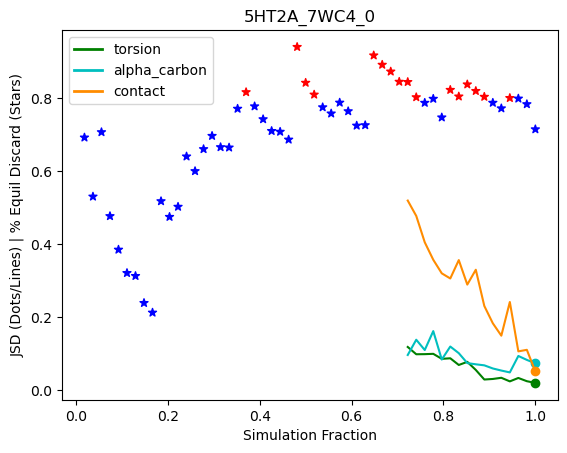

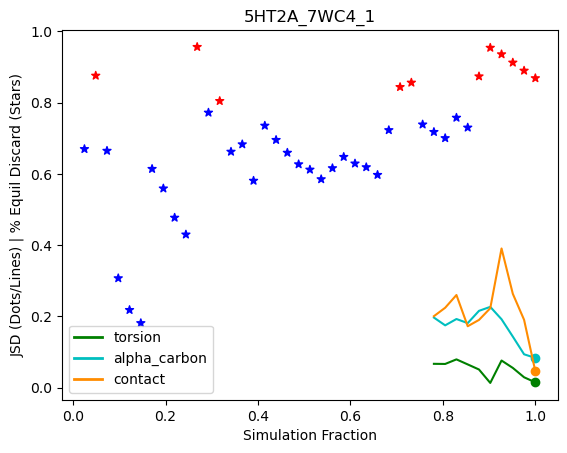

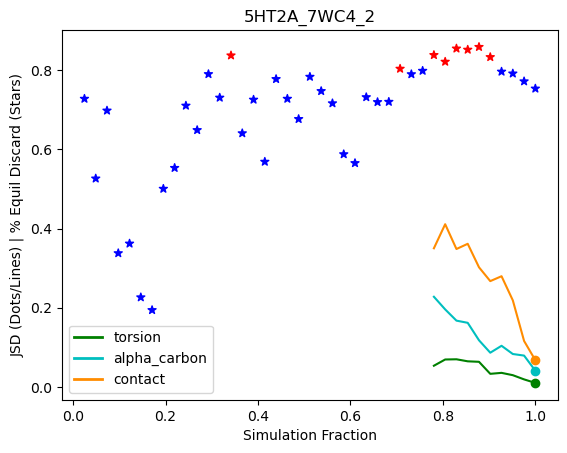

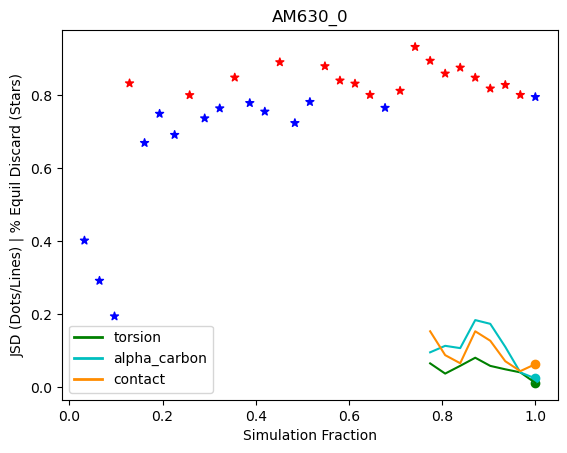

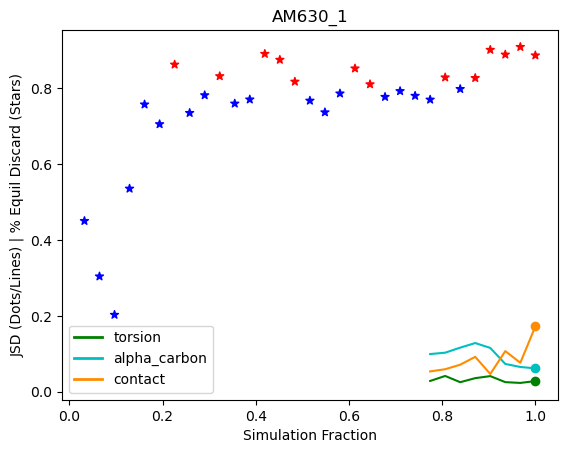

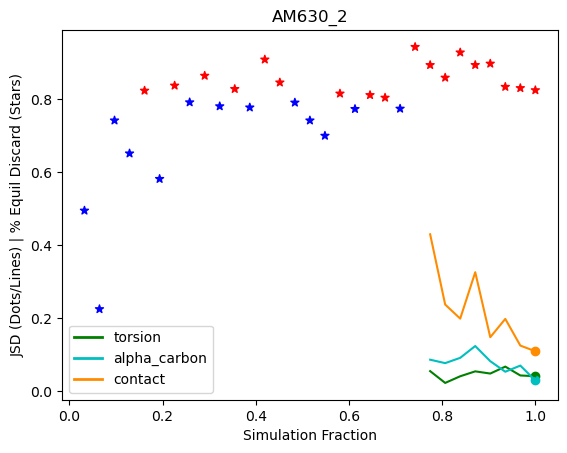

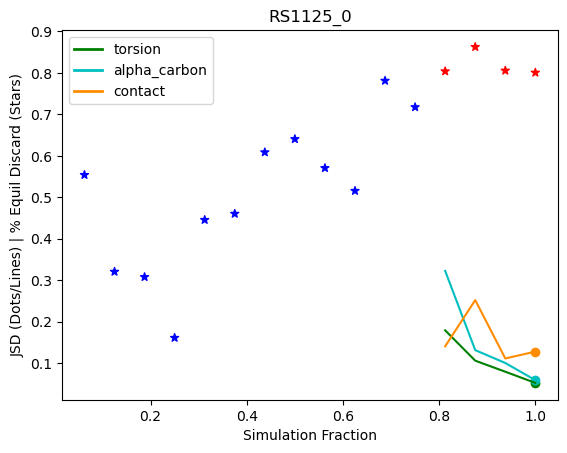

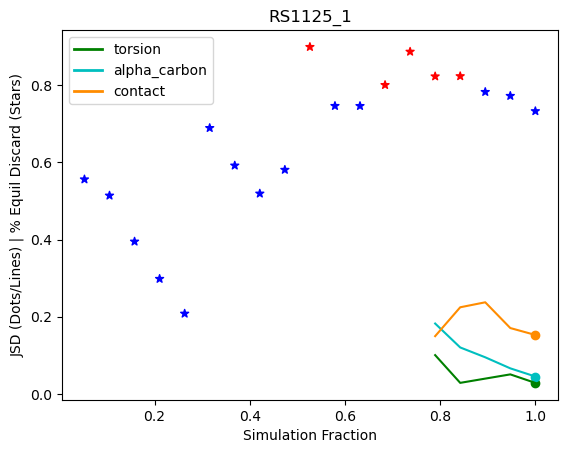

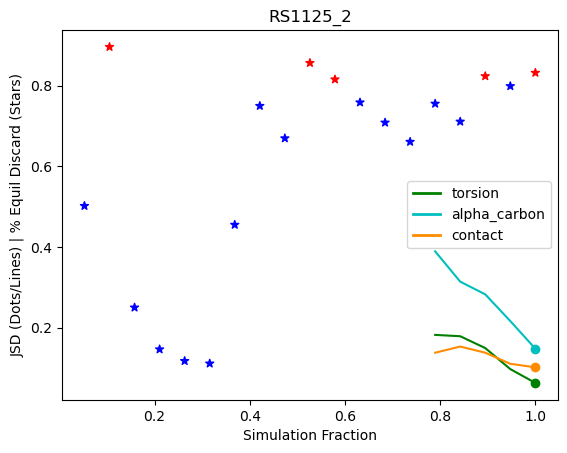

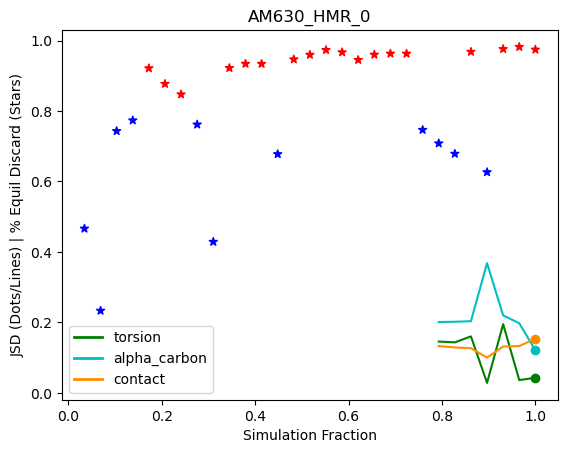

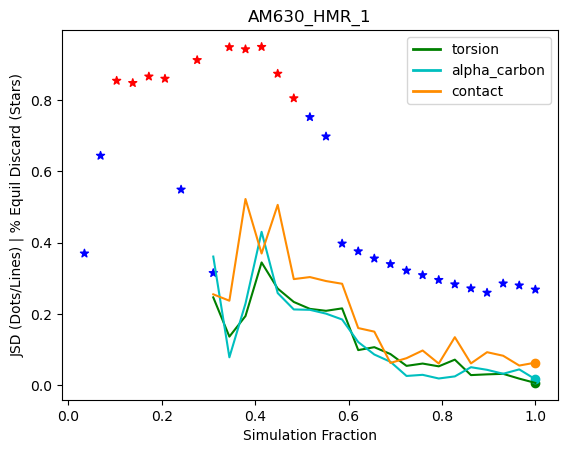

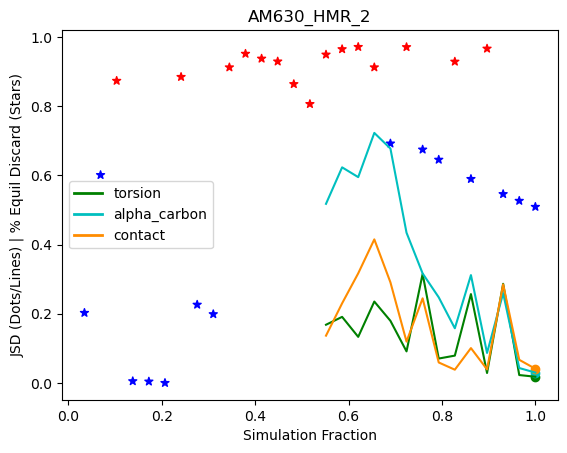

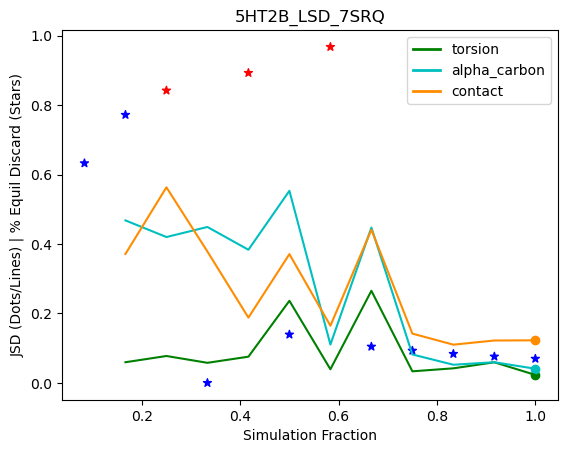

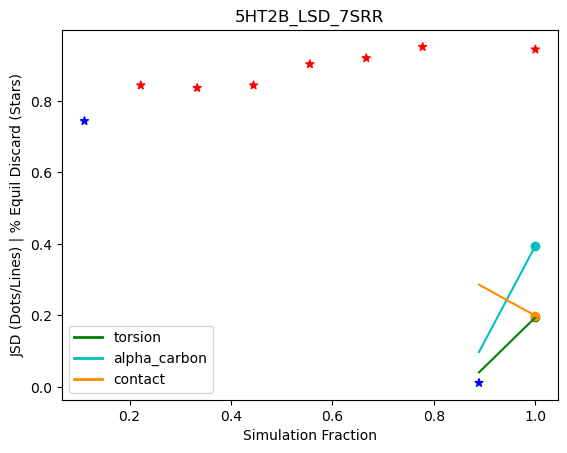

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
titles = ['5HT2A_7WC4_0', '5HT2A_7WC4_1', '5HT2A_7WC4_2',
          'AM630_0', 'AM630_1', 'AM630_2',
          'RS1125_0', 'RS1125_1', 'RS1125_2',
          #'RS1126_0', 'RS1126_1', 'RS1126_2',
          'AM630_HMR_0', 'AM630_HMR_1', 'AM630_HMR_2',
          '5HT2B_LSD_7SRQ', '5HT2B_LSD_7SRR', '5HT2B_LSD_7SRS']

for i, metrics in enumerate(metricses):
    plt.clf()
    history=True
    func='jsd'
    plot_convergence_metric(metrics, func=func, distype='torsion', history=history)
    plot_convergence_metric(metrics, func=func, distype='alpha_carbon', history=history)
    plot_convergence_metric(metrics, func=func, distype='contact', history=history)
    add_equil_metric_to_plot(metrics)
    lines, keys = [Line2D([0], [0], color=color_map[key], lw=2) for key in color_map.keys()], [key for key in color_map.keys()]
    plt.legend(lines, keys)
    plt.xlabel('Simulation Fraction')
    plt.ylabel('JSD (Dots/Lines) | % Equil Discard (Stars)')
    plt.title(titles[i])
    plt.show()